In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import svm
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
## load dataset
df=pd.read_csv('/content/MainDiabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
## statistic of dataset
diabetes=df[df['Outcome']==1].shape
non_diabetes=df[df['Outcome']==0].shape
print("Has Diabeties {}, Does not have Diabetes {}".format(diabetes,non_diabetes))
df.describe()

Has Diabeties (268, 9), Does not have Diabetes (500, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


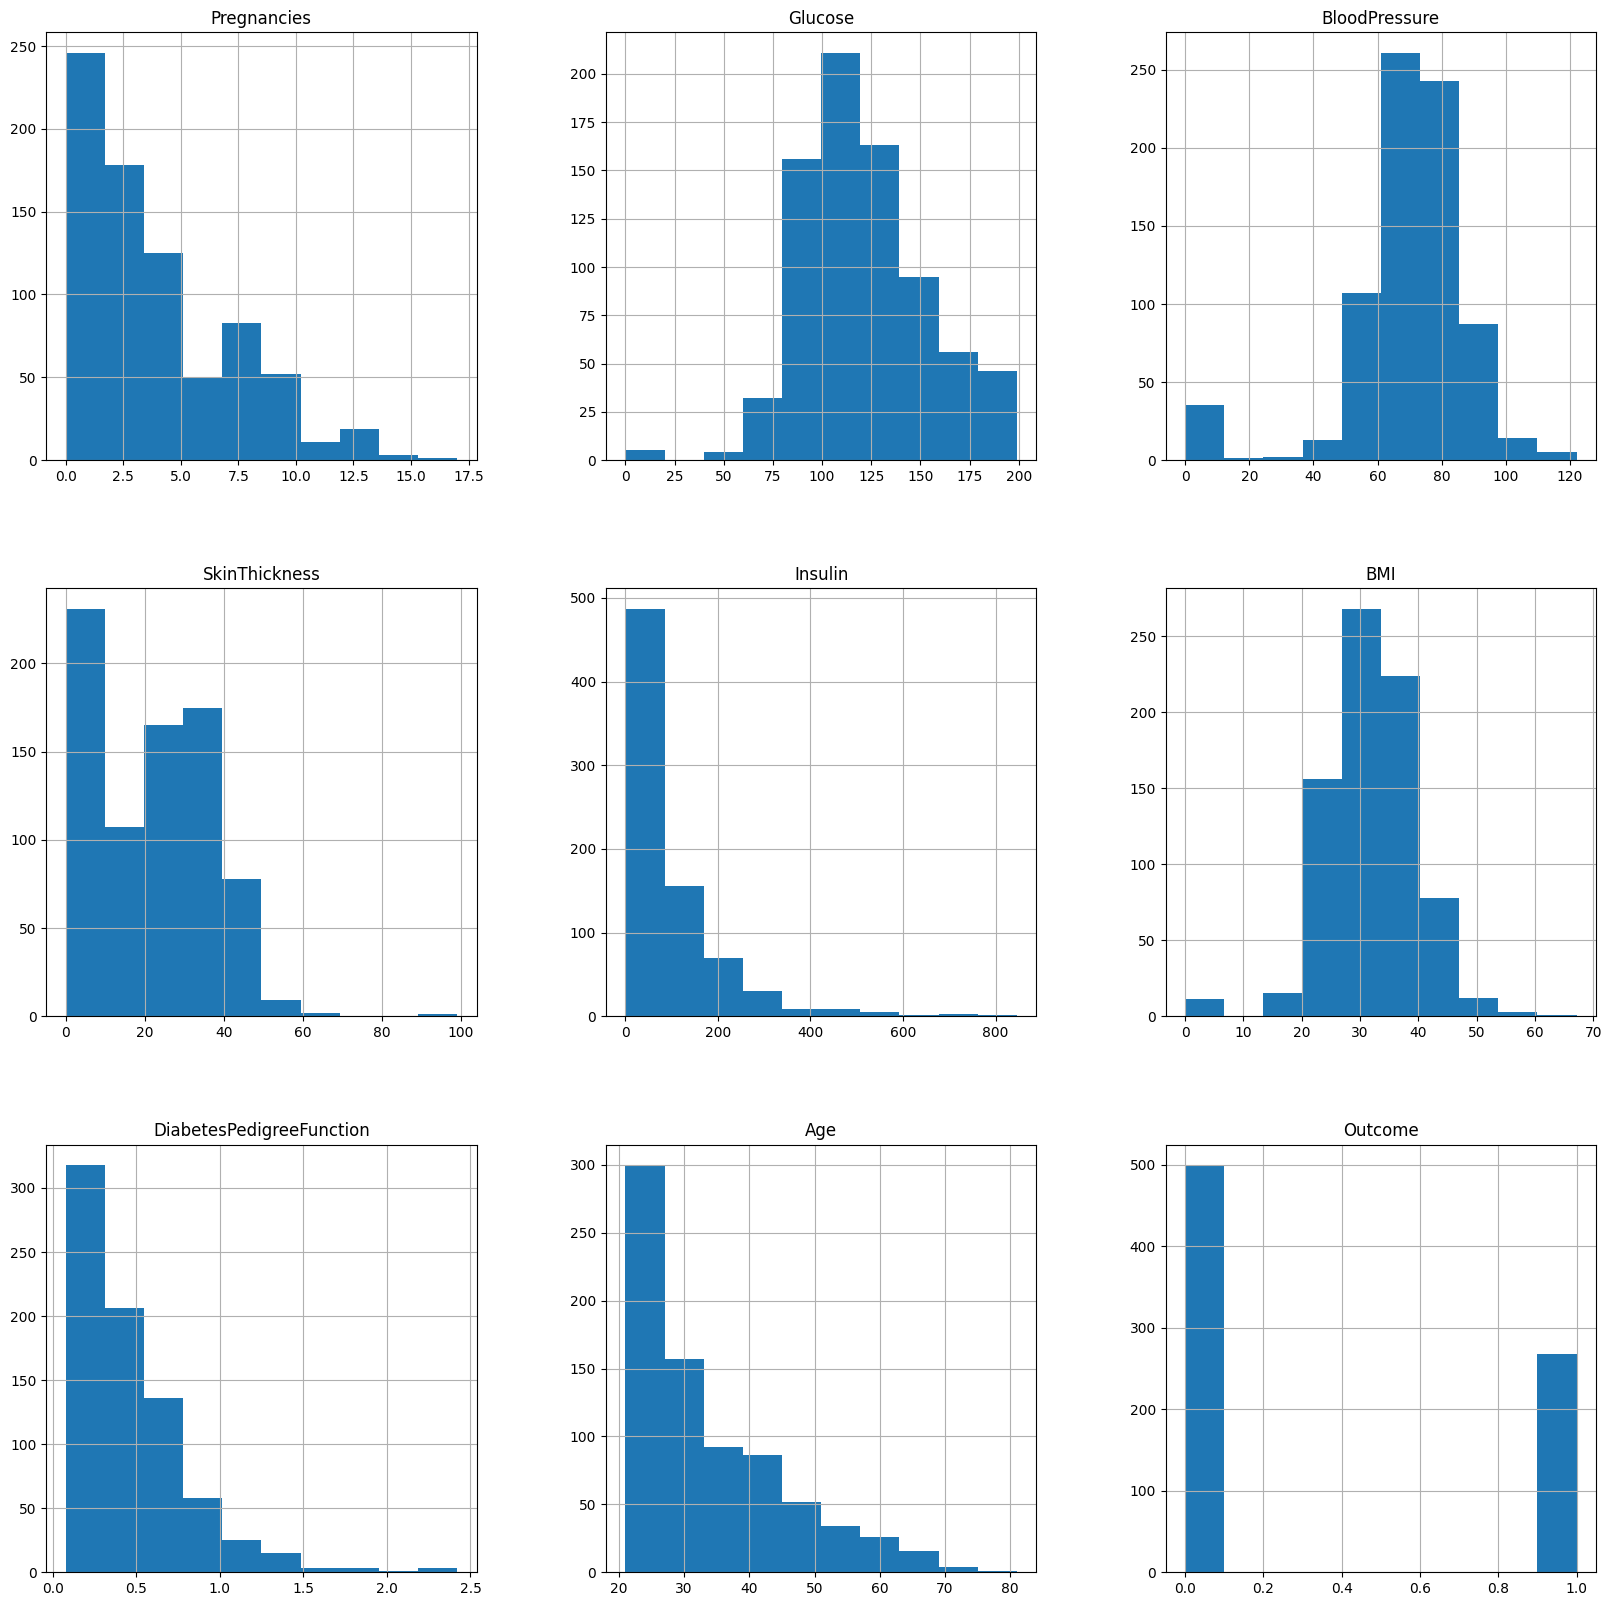

In [ ]:
# x-axis range , y-axis abundance
histo = df.hist(figsize = (20,20))

In [ ]:
df ['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

In [ ]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [ ]:
#### pre-process Insulin & SkinThickness

df_copy=df.copy(deep=True)
## replace 0 with NaN to fill out easily

df_copy[['Insulin','SkinThickness']]=df_copy[['Insulin','SkinThickness']].replace(0,np.NaN)
## The median is the middle point of a number set, in which half the numbers are above the median and half are below
## replace null value with median
df_copy['Insulin'].fillna(df_copy['Insulin'].median(),inplace=True)
df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].median(),inplace=True)
## test result
# print(df_copy[df_copy['Insulin']==0].shape,df_copy[df_copy['SkinThickness']==0].shape)



In [ ]:
# pre-process Blood Pressure , BMI & Glucose invalid values
# as blood pressure & glucose are critical for determing diabeties it should not be invalid
# their null fraction is very small so it should better to remove invalid entries
df_copy=df_copy[(df_copy['BloodPressure']!=0) & (df_copy['BMI']!=0) & (df_copy['Glucose']!=0)]
# test result
# print(df_copy[df_copy['BloodPressure']==0].shape,df_copy[df_copy['BMI']==

In [ ]:
## split dataset on outcome from 70% to 30%
X=df_copy.drop('Outcome',axis=1)
y=df_copy['Outcome']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=10)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(506, 8)
(218, 8)
(506,)
(218,)


In [ ]:
#1. Naive Bayes
naive = GaussianNB()
naive.fit(X_train,y_train)
predicted_naive=naive.predict(X_test)
cm_naive=metrics.confusion_matrix(y_test,predicted_naive)
accuracy_naive=metrics.accuracy_score(y_test,predicted_naive)

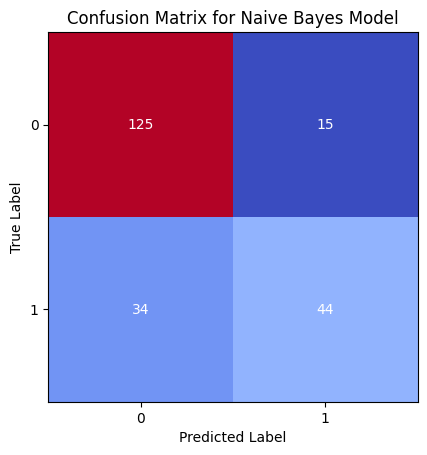

In [ ]:
#from sklearn.metrics import confusion_matrix, plot_confusion_matrix
#from sklearn.datasets import load_diabetes

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
class_names = ['No Diabetes', 'Diabetes']
fig, ax = plt.subplots()
ax.imshow(cm_naive, cmap='coolwarm')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_title('Confusion Matrix for Naive Bayes Model')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
for i in range(len(class_names)):
  for j in range(len(class_names)):
    text = cm_naive[i, j]
    ax.text(j, i, text, ha='center', va='center', color='white')



In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy : \n {} ".format(cm_naive,accuracy_naive))
# Accuracy : 0.7752293577981652

Confusion Matrix : 
 [[125  15]
 [ 34  44]]  
 Accuracy : 
 0.7752293577981652 


In [ ]:
average_precision = average_precision_score(y_test, predicted_naive)
print("Average Precision : {}" .format (average_precision))

Average Precision : 0.5766499607270872


In [ ]:
print(classification_report(y_test, predicted_naive))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       140
           1       0.75      0.56      0.64        78

    accuracy                           0.78       218
   macro avg       0.77      0.73      0.74       218
weighted avg       0.77      0.78      0.77       218



/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


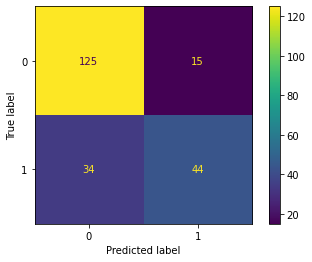

In [ ]:
plot_confusion_matrix(naive, X_test, y_test)
plt.show()

In [ ]:
# 3. KNN Implementation
knn=KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train,y_train)
predicted_knn=knn.predict(X_test)
cm_knn=metrics.confusion_matrix(y_test,predicted_knn)
accuracy_knn=metrics.accuracy_score(y_test,predicted_knn)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


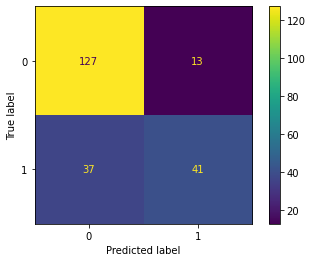

In [ ]:
plot_confusion_matrix(knn, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy :  {} ".format(cm_knn,accuracy_knn))

Confusion Matrix : 
 [[127  13]
 [ 37  41]]  
 Accuracy :  0.7706422018348624 


In [ ]:
# k=3 (accuracy  0.7385321100917431) k=5 ( Accuracy :0.7522935779816514 )
# k=11 (Accuracy :  0.7706422018348624) k=13 ( Accuracy :  0.7614678899082569 )
average_precision = average_precision_score(y_test, predicted_knn)
print("Average Precision : {}".format (average_precision))

Average Precision : 0.5688225864066843


In [ ]:
print(classification_report(y_test, predicted_knn))

              precision    recall  f1-score   support

           0       0.77      0.91      0.84       140
           1       0.76      0.53      0.62        78

    accuracy                           0.77       218
   macro avg       0.77      0.72      0.73       218
weighted avg       0.77      0.77      0.76       218



In [ ]:
# 2 Decision Tree
d_tree=tree.DecisionTreeClassifier()
d_tree.fit(X_train,y_train)
predicted_tree=d_tree.predict(X_test)
accuracy_tree=metrics.accuracy_score(y_test,predicted_tree)
cm_dt=metrics.confusion_matrix(y_test,predicted_tree)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


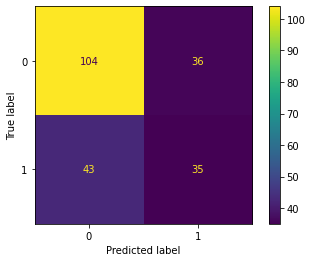

In [ ]:
plot_confusion_matrix(d_tree, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy :  {} ".format(cm_dt,accuracy_tree))

Confusion Matrix : 
 [[104  36]
 [ 43  35]]  
 Accuracy :  0.6376146788990825 


In [ ]:
average_precision = average_precision_score(y_test, predicted_tree)
print("Average precision : {}" .format (average_precision))

Average precision : 0.418446695226641


In [ ]:
print(classification_report(y_test, predicted_tree))

              precision    recall  f1-score   support

           0       0.74      0.80      0.77       140
           1       0.58      0.49      0.53        78

    accuracy                           0.69       218
   macro avg       0.66      0.64      0.65       218
weighted avg       0.68      0.69      0.68       218



In [ ]:
# 3. Logistic regression
logisticRegr= LogisticRegression()
logisticRegr.fit(X_train,y_train)
predict_lg = logisticRegr.predict(X_test)
accuarcy_lg=metrics.accuracy_score(y_test,predict_lg)
cm_lg=metrics.confusion_matrix(y_test,predict_lg)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


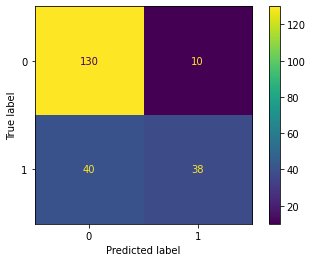

In [ ]:
plot_confusion_matrix(logisticRegr, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy :  {} ".format(cm_lg,accuarcy_lg))
#0.7752293577981652


Confusion Matrix : 
 [[130  10]
 [ 40  38]]  
 Accuracy :  0.7706422018348624 


In [ ]:
average_precision = average_precision_score(y_test, predict_lg)
print("Average Precision : {}".format (average_precision))

Average Precision : 0.5691699992158707


In [ ]:
print(classification_report (y_test, predict_lg))

              precision    recall  f1-score   support

           0       0.76      0.93      0.84       140
           1       0.79      0.49      0.60        78

    accuracy                           0.77       218
   macro avg       0.78      0.71      0.72       218
weighted avg       0.77      0.77      0.75       218



In [ ]:
#5. Random Forest
from sklearn import metrics

rfm = RandomForestClassifier(n_estimators=70, oob_score=True, n_jobs=-1, random_state=101, max_features = None, min_samples_leaf = 30)
rfm = rfm.fit(X_train, y_train)
pred_forest=rfm.predict(X_test)
accuracy_forest=metrics.accuracy_score(y_test,pred_forest)
cm_rf=metrics.confusion_matrix(y_test,pred_forest)


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


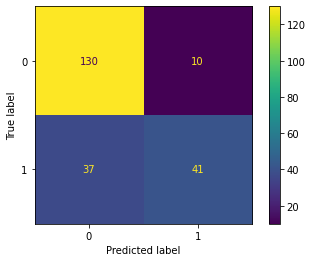

In [ ]:
plot_confusion_matrix(rfm, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy :  {} ".format(cm_rf,accuracy_forest))


Confusion Matrix : 
 [[130  10]
 [ 37  41]]  
 Accuracy :  0.7844036697247706 


In [ ]:
average_precision = average_precision_score(y_test, pred_forest)
print("Average Precision : {}" .format (average_precision))

Average Precision : 0.5922989285104774


In [ ]:
print(classification_report (y_test, pred_forest))

              precision    recall  f1-score   support

           0       0.78      0.93      0.85       140
           1       0.80      0.53      0.64        78

    accuracy                           0.78       218
   macro avg       0.79      0.73      0.74       218
weighted avg       0.79      0.78      0.77       218



In [ ]:
# 6. SVM
#Data Standardization
scaler = StandardScaler()
scaler.fit(X)
standardized_data = scaler.transform(X)
print(standardized_data)

[[ 0.63502182  0.84993279 -0.03237751 ...  0.16456174  0.45842062
   1.41607523]
 [-0.85286102 -1.20026207 -0.51737031 ... -0.85226209 -0.37269083
  -0.19994691]
 [ 1.23017496  1.98892994 -0.67903458 ... -1.33162189  0.59392792
  -0.11489311]
 ...
 [ 0.33744525 -0.02872215 -0.03237751 ... -0.9103663  -0.69188581
  -0.28500071]
 [-0.85286102  0.13399173 -1.00236311 ... -0.34385017 -0.37871338
   1.16091384]
 [-0.85286102 -0.93991986 -0.19404178 ... -0.30027201 -0.48109667
  -0.88037728]]


In [ ]:
X = standardized_data
Y = df['Outcome']
print(X)

[[ 0.63502182  0.84993279 -0.03237751 ...  0.16456174  0.45842062
   1.41607523]
 [-0.85286102 -1.20026207 -0.51737031 ... -0.85226209 -0.37269083
  -0.19994691]
 [ 1.23017496  1.98892994 -0.67903458 ... -1.33162189  0.59392792
  -0.11489311]
 ...
 [ 0.33744525 -0.02872215 -0.03237751 ... -0.9103663  -0.69188581
  -0.28500071]
 [-0.85286102  0.13399173 -1.00236311 ... -0.34385017 -0.37871338
   1.16091384]
 [-0.85286102 -0.93991986 -0.19404178 ... -0.30027201 -0.48109667
  -0.88037728]]


In [ ]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [ ]:
SupportV = svm.SVC(kernel='linear')
# Training SVM
SupportV = SupportV.fit(X_train, y_train)
# Accuracy score of training data
SupportV_pred = SupportV.predict(X_train)
accuracy_SupportV = accuracy_score(SupportV_pred, y_train)
cm_SupportV=metrics.confusion_matrix(y_train, SupportV_pred)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


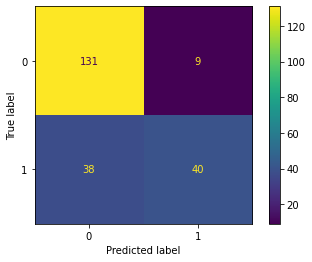

In [ ]:
plot_confusion_matrix(SupportV, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy :  {} ".format(cm_SupportV,accuracy_SupportV))


Confusion Matrix : 
 [[292  43]
 [ 78  93]]  
 Accuracy :  0.7608695652173914 


In [ ]:
average_precision = average_precision_score(y_train, SupportV_pred)
print("Average Precision : {}" .format (average_precision))

Average Precision : 0.5260542223962603


In [ ]:
print(classification_report (y_train, SupportV_pred))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       335
           1       0.68      0.54      0.61       171

    accuracy                           0.76       506
   macro avg       0.74      0.71      0.72       506
weighted avg       0.75      0.76      0.75       506

